# AirBnB Listing Analysis

Analyze AirBnB listings in Paris to determine the impact of recent regulations

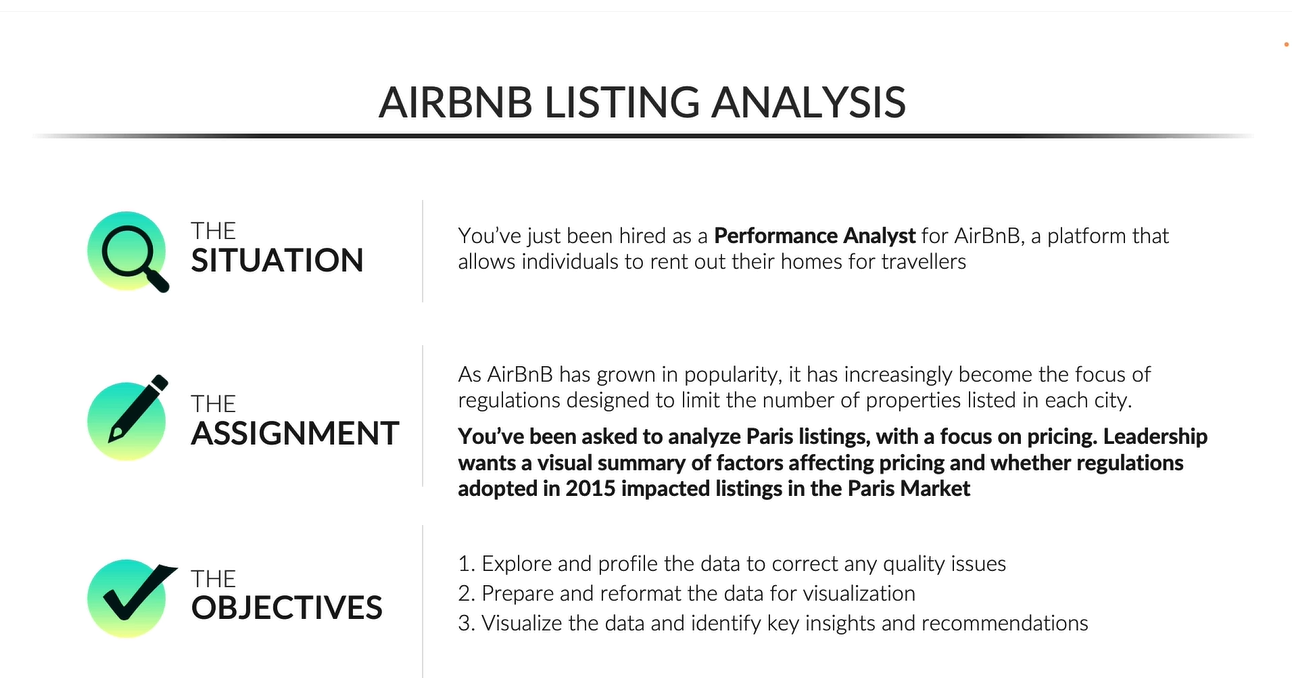

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Objective 1: Profile & QA the data

Your first objective is to read in the AirBnB listings data, calculate basic profiling metrics, change column datatypes as necessary, and filter down to only Paris Listings. Tasks:
* Import/Open the Listings.csv file
* Cast any date columns as a datetime format
* Filter the data down to rows where the city is Paris, and keep only the columns ‘host_since’, ‘neighbourhood’, ‘city’, ‘accommodates’, and ‘price’
* QA the Paris listings data: check for missing values, and calculate the minimum, maximum, and average for each numeric field

In [9]:
# Import/Open Listings.csv file & Cast any date columns as a datetime format
listings_df = pd.read_csv(
    'Listings.csv', 
    parse_dates = ['host_since'],
    encoding='latin1'
)

listings_df.info(memory_usage='deep')

C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_138012\4149112928.py:2: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  listings_df = pd.read_csv(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [10]:
listings_df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [11]:
# Filter the data down to rows where the city is Paris, and keep only the columns ‘host_since’, ‘neighbourhood’, ‘city’, ‘accommodates’, and ‘price’

paris_listings_df = listings_df.query('city == "Paris"').loc[:, ['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]

paris_listings_df.head()

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60


In [12]:
# QA the Paris listings data: check for missing values, and calculate the minimum, maximum, and average for each numeric field

paris_listings_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 10.0 MB


In [15]:
paris_listings_df['host_since'].isna().sum()

33

In [16]:
# QA the Paris listings data: check for missing values, and calculate the minimum, maximum, and average for each numeric field
paris_listings_df.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [17]:
paris_listings_df.query("price == 0 and accommodates == 0").count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

## Objective 2: Prepare the data for visualization

Your second objective is to produce DataFrames that will be used in visualizations by aggregating and manipulating the listings data in several ways. Tasks:
* Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)
* Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood, group by the ‘accommodations’ column, and add the mean price for each value of ‘accommodates’ (sorted low to high)
* Create a table called paris_listings_over_time grouped by the ‘host_since’ year, and calculate the average price and count of rows representing the number of new hosts

In [18]:
# Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)
paris_listings_neighbourhood = (
    paris_listings_df
    .groupby('neighbourhood')
    .agg({'price': 'mean'})
    .sort_values(by='price', ascending=True)
)

paris_listings_neighbourhood.head()

,price
neighbourhood,
Menilmontant,74.942257
Buttes-Chaumont,82.690182
Buttes-Montmartre,87.209479
Reuilly,89.058402
Popincourt,90.559459


In [19]:
# Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood, group by the ‘accommodations’ column, 
# and add the mean price for each value of ‘accommodates’ (sorted low to high)
paris_listings_accommodates = (
    paris_listings_df
    .query("neighbourhood == 'Elysee'")
    .groupby('accommodates')
    .agg({'price': 'mean','neighbourhood': 'count'})
    .sort_values(by='price', ascending=True)
)

paris_listings_accommodates.head()

,price,neighbourhood
accommodates,,
0,0.000000,6
1,79.522222,90
3,152.828767,146
2,155.103352,716
4,212.096070,458


In [20]:
# Create a table called paris_listings_over_time grouped by the ‘host_since’ year,
# and calculate the average price and count of rows representing the number of new hosts

paris_listings_over_time = (
    paris_listings_df
    .set_index('host_since')
    .resample('Y')
    .agg(
        {
        'price': 'mean',
        'neighbourhood': 'count'
        }
    )

)

paris_listings_over_time.head()

,price,neighbourhood
host_since,,
2008-12-31,77.750000,4
2009-12-31,159.641509,106
2010-12-31,125.031250,416
2011-12-31,124.828230,1339
2012-12-31,111.578615,4592


## Objective 3: Visualize the data and summarize findings

Your final objective is to build visuals to show the number of new hosts by year, overall average price by year and neighborhood, and average price for various types of listings in Paris' most expensive neighborhood. Tasksa:
* Create a horizontal bar chart of the average price by neighborhood in Paris, and make sure to add a title and change axis labels as needed
* Create a horizontal bar chart of the average price by ‘accommodates’ in Paris’ most expensive neighborhood, and make sure to add a title and change axis labels as needed
* Create two line charts: one showing the count of new hosts over time, and one showing average price. Set the y-axis limit to 0, add a title, and change axis labels as needed
* Based on your findings, what insights do you have about the impact of the 2015 regulations on new hosts and prices?
* BONUS: Create a dual axis line chart to show both new hosts and average price over time


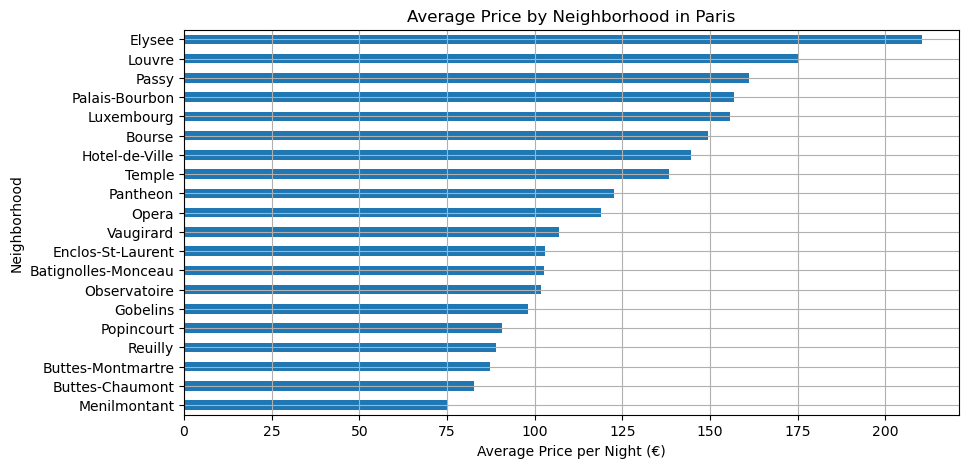

In [52]:
# Create a horizontal bar chart of the average price by neighborhood in Paris, and make sure to add a title and change axis labels as needed

from matplotlib.pyplot import legend


paris_listings_neighbourhood.plot.barh(
    title = 'Average Price by Neighborhood in Paris',
    xlabel = 'Average Price per Night (€)',
    ylabel = 'Neighborhood',
    grid = True,
    figsize = (10,5),
    legend=False
);

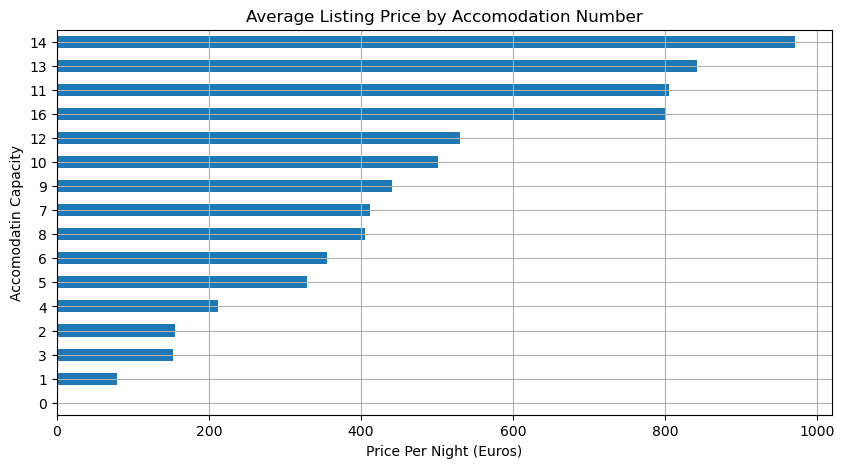

In [58]:
# Create a horizontal bar chart of the average price by ‘accommodates’ in Paris’ most expensive neighborhood, and make sure to add a title and change axis labels as needed

paris_listings_accommodates.loc[:, 'price'].plot.barh(
    title = 'Average Listing Price by Accomodation Number',
    xlabel = 'Price Per Night (Euros)',
    ylabel = 'Accomodatin Capacity',
    grid = True,
    figsize = (10,5),
    legend = False
);


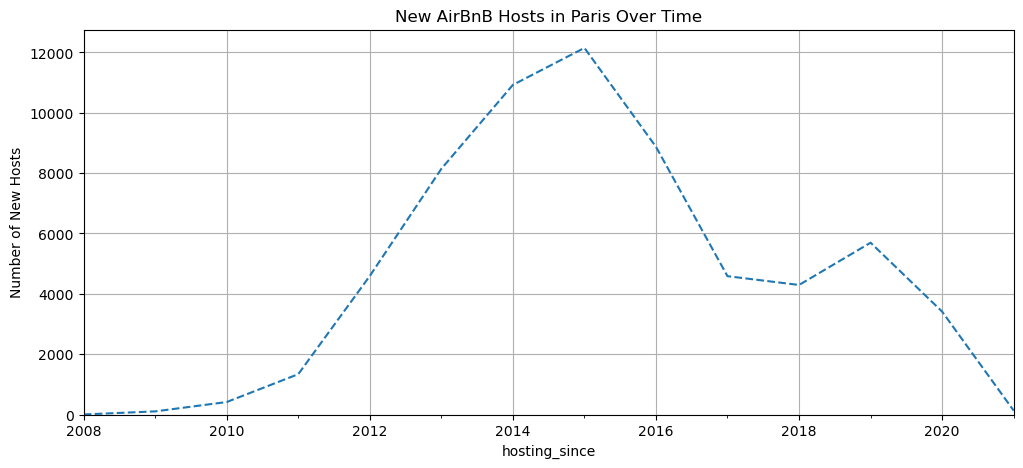

In [60]:
# Create two line charts: one showing the count of new hosts over time, and one showing average price. 
# Set the y-axis limit to 0, add a title, and change axis labels as needed
(
   paris_listings_over_time['neighbourhood']
).plot(
    title = 'New AirBnB Hosts in Paris Over Time',
    xlabel = 'hosting_since',
    ylabel = 'Number of New Hosts',
    style = '--',
    grid = True,
    figsize = (12,5),
    ylim= (0, None)
);


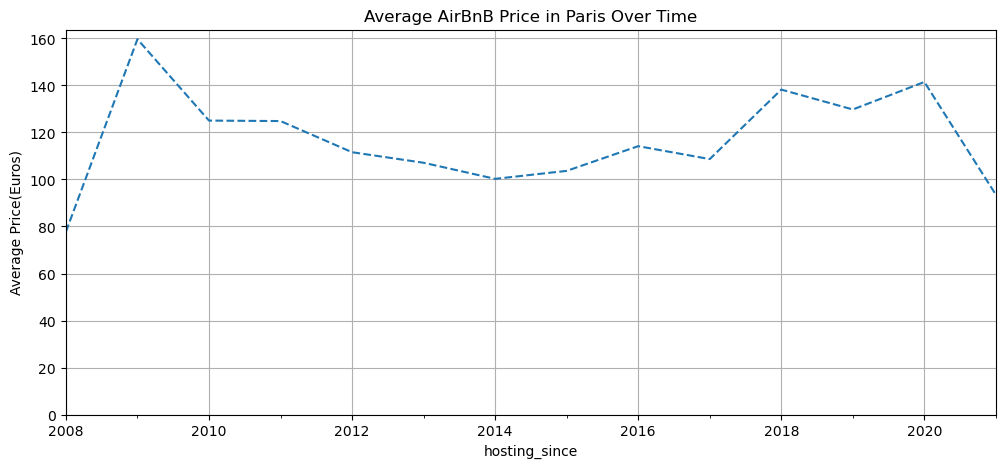

In [61]:
(
   paris_listings_over_time['price']
).plot(
    title = 'Average AirBnB Price in Paris Over Time',
    xlabel = 'hosting_since',
    ylabel = 'Average Price(Euros)',
    style = '--',
    grid = True,
    figsize = (12,5),
    ylim= (0, None)
);


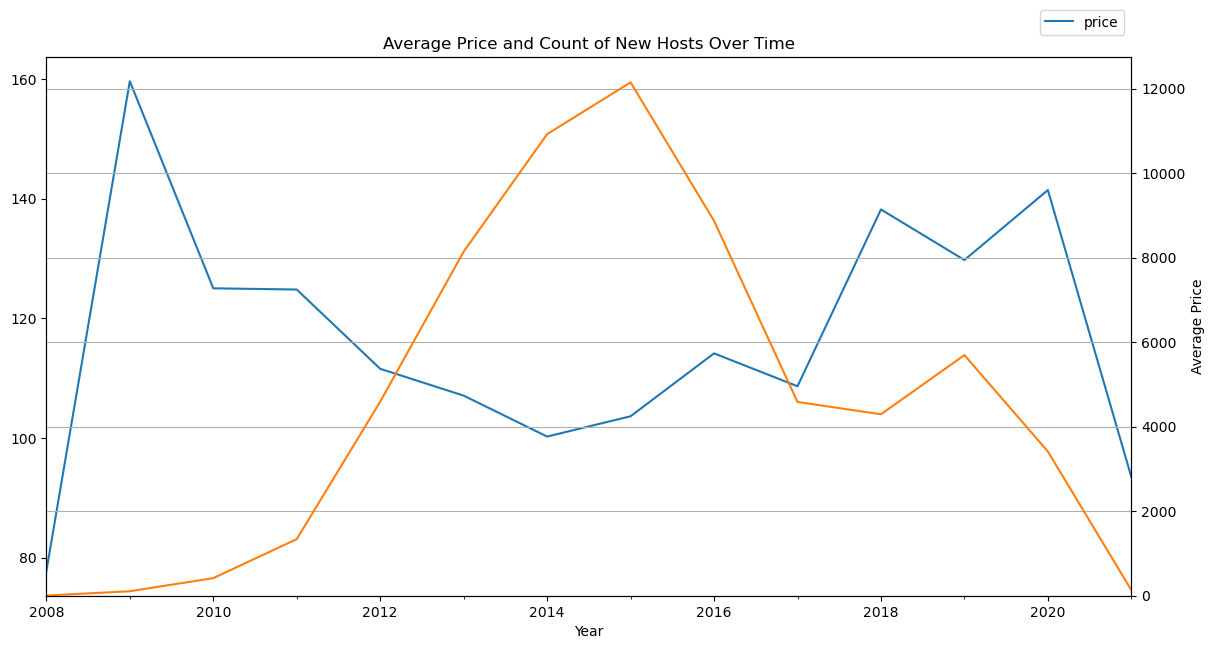

In [ ]:
# BONUS: Create a dual axis line chart to show both new hosts and average price over time

(
    paris_listings_df
    .set_index('host_since')
    .resample('Y')
    .agg(
        {
        'price': 'mean',
        'neighbourhood': 'count'
        }
     )
).plot(
    title = 'Average Price and Count of New Hosts Over Time',
    xlabel = 'Year',
    ylabel = 'Average Price',
    grid = True,
    figsize = (14,7),
    ylim= (0, None),
    secondary_y = 'neighbourhood'
).legend(bbox_to_anchor=(1.0, 1.1));